In [ ]:
import math
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.nn import TransformerEncoder, TransformerEncoderLayer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)

In [ ]:
class TransformerLanguageModel(nn.Module):
    def __init__(self, ntoken, ninp, nhead, nhid, nlayers, dropout=0.2):
        super().__init__()
        self.encoder = nn.Embedding(ntoken, ninp)
        self.pos_encoder = PositionalEncoding(ninp, dropout)
        layer = TransformerEncoderLayer(ninp, nhead, nhid, dropout)
        self.transformer_encoder = TransformerEncoder(layer, nlayers)
        self.decoder = nn.Linear(ninp, ntoken)
        self.ninp = ninp

    def _mask(self, sz):
        return torch.triu(torch.ones(sz, sz) * float('-inf'), diagonal=1)

    def forward(self, src):
        mask = self._mask(src.size(0)).to(src.device)
        x = self.encoder(src) * math.sqrt(self.ninp)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x, mask)
        return self.decoder(x)

In [ ]:
class RNNLanguageModel(nn.Module):
    def __init__(self, ntoken, ninp, nhid, nlayers, dropout=0.2):
        super().__init__()
        self.encoder = nn.Embedding(ntoken, ninp)
        self.rnn = nn.LSTM(ninp, nhid, nlayers, dropout=dropout)
        self.decoder = nn.Linear(nhid, ntoken)

    def forward(self, src, hidden=None):
        emb = self.encoder(src)
        out, hidden = self.rnn(emb, hidden)
        return self.decoder(out), hidden

In [ ]:
vocab_size = 500
ninp = 64
nhid = 128
nlayers = 2
nhead = 4

transformer = TransformerLanguageModel(vocab_size, ninp, nhead, nhid, nlayers).to(device)
rnn = RNNLanguageModel(vocab_size, ninp, nhid, nlayers).to(device)

In [ ]:
def train_step(model, optimizer, criterion, seq_len):
    src = torch.randint(0, vocab_size, (seq_len, 8)).to(device)
    tgt = torch.randint(0, vocab_size, (seq_len, 8)).to(device)
    optimizer.zero_grad()
    if isinstance(model, RNNLanguageModel):
        out, _ = model(src)
    else:
        out = model(src)
    loss = criterion(out.view(-1, vocab_size), tgt.view(-1))
    loss.backward()
    optimizer.step()
    return loss.item()

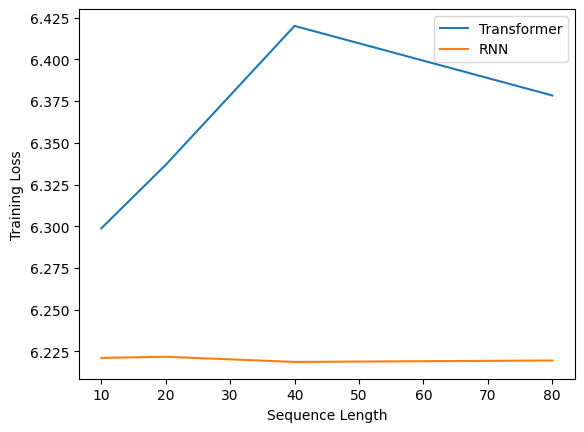

In [ ]:
criterion = nn.CrossEntropyLoss()
opt_t = torch.optim.Adam(transformer.parameters(), lr=1e-3)
opt_r = torch.optim.Adam(rnn.parameters(), lr=1e-3)

seq_lengths = [10, 20, 40, 80]
loss_t, loss_r = [], []

for s in seq_lengths:
    loss_t.append(train_step(transformer, opt_t, criterion, s))
    loss_r.append(train_step(rnn, opt_r, criterion, s))

plt.figure()
plt.plot(seq_lengths, loss_t, label='Transformer')
plt.plot(seq_lengths, loss_r, label='RNN')
plt.xlabel('Sequence Length')
plt.ylabel('Training Loss')
plt.legend()
plt.show()

Embedding shape: torch.Size([20, 64])


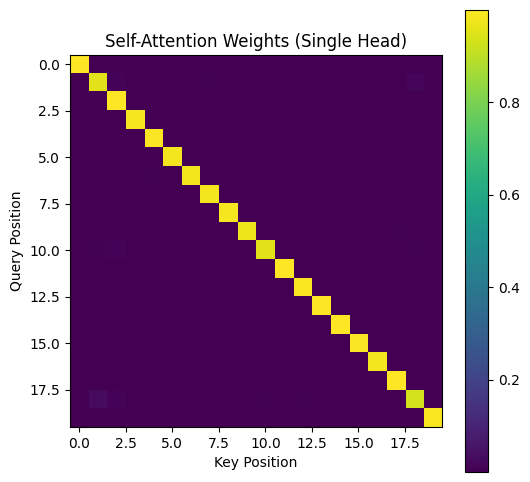

In [ ]:
import math
import torch
import matplotlib.pyplot as plt

transformer.eval()

# Create dummy input
seq_len = 20
src = torch.randint(0, vocab_size, (seq_len, 1)).to(device)

emb = transformer.encoder(src)

# Remove batch dimension
# Shape: [seq_len, emb_dim]
emb = emb.squeeze(1)

print("Embedding shape:", emb.shape)

# Compute scaled dot-product self-attention
Q = emb                                # [seq_len, emb_dim]
K = emb                                # [seq_len, emb_dim]

scores = (Q @ K.T) / math.sqrt(Q.size(-1))   # [seq_len, seq_len]
attn = torch.softmax(scores, dim=-1)

# Plot attention heatmap
plt.figure(figsize=(6, 6))
plt.imshow(attn.detach().cpu(), cmap="viridis")
plt.colorbar()
plt.title("Self-Attention Weights (Single Head)")
plt.xlabel("Key Position")
plt.ylabel("Query Position")
plt.show()
